<a href="https://colab.research.google.com/github/AndresDVS/Entrega2/blob/main/S20_M%C3%B3dulo_1_Actividad_did%C3%A1ctica_2_M1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SIMULADOR DE YATZHEE CON MONTECARLO
1. Simular una sola partida (con graficos detallados)
2. Simular multiples partidas (analisis estadistico)

Selecciona una opcion (1 o 2): 2
Cuantas partidas quieres simular? (ej: 1000, 5000, 10000): 1000
Simulando 1000 partidas...
Completadas 1000 de 1000 partidas

RESULTADOS DE SIMULACION MULTIPLE
Partidas simuladas: 1000
Victorias Jugador 1: 499 (49.90%)
Victorias Jugador 2: 481 (48.10%)
Empates: 20 (2.00%)
Puntaje promedio Jugador 1: 137.47
Puntaje promedio Jugador 2: 135.18


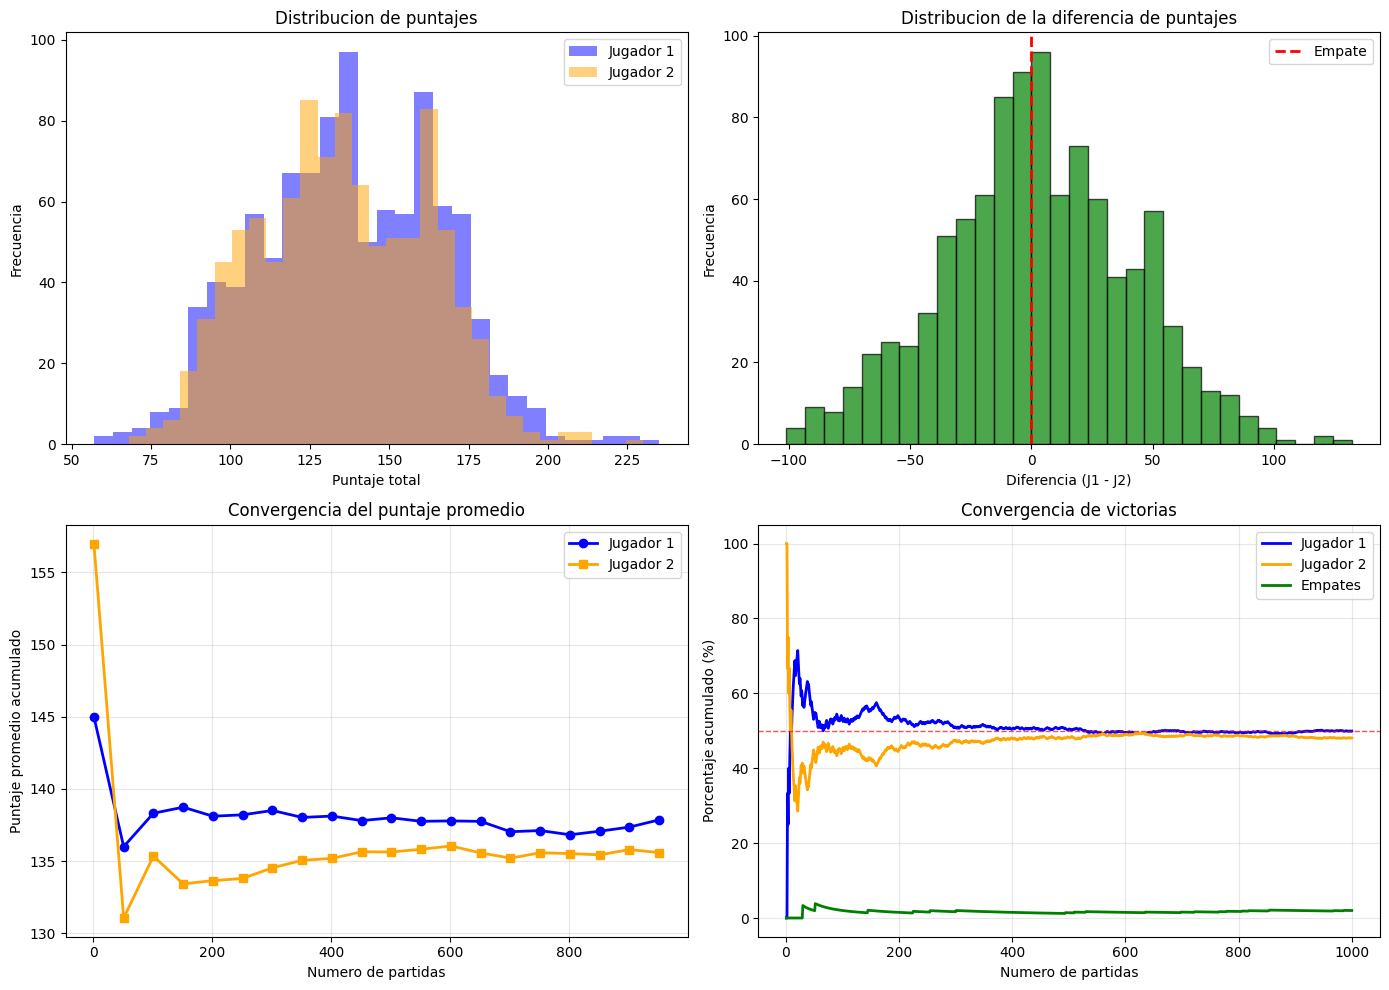

In [ ]:
import random
from collections import Counter
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple
from functools import lru_cache
import matplotlib.pyplot as plt

CONFIG = {
    "sims_por_mascara": 80,
    "semilla": 42
}

if CONFIG["semilla"] is not None:
    random.seed(CONFIG["semilla"])

CARAS = 6
NUM_DADOS = 5

CATEGORIAS = [
    "unos", "dos", "tres", "cuatros", "cincos", "seis",
    "trio", "cuarteto", "full_house", "escalera_chica",
    "escalera_grande", "yatzhee", "chance"
]

def lanzar_dado():
    return random.randint(1, CARAS)

def lanzar_dados(valores, bloqueados):
    for i, bloq in enumerate(bloqueados):
        if not bloq:
            valores[i] = lanzar_dado()

def tiene_secuencia(valores, largo):
    unicos = sorted(set(valores))
    if not unicos:
        return False
    max_racha = 1
    racha = 1
    for i in range(1, len(unicos)):
        if unicos[i] == unicos[i-1] + 1:
            racha += 1
            max_racha = max(max_racha, racha)
        else:
            racha = 1
    return max_racha >= largo

def puntuar(categoria, dados):
    conteo = Counter(dados)
    freqs = list(conteo.values())
    total = sum(dados)
    if categoria in ["unos","dos","tres","cuatros","cincos","seis"]:
        num = {"unos":1,"dos":2,"tres":3,"cuatros":4,"cincos":5,"seis":6}[categoria]
        return conteo.get(num, 0) * num
    if categoria == "trio":
        return total if any(f >= 3 for f in freqs) else 0
    if categoria == "cuarteto":
        return total if any(f >= 4 for f in freqs) else 0
    if categoria == "full_house":
        return 25 if (2 in freqs and 3 in freqs) else 0
    if categoria == "escalera_chica":
        return 30 if tiene_secuencia(dados, 4) else 0
    if categoria == "escalera_grande":
        return 40 if tiene_secuencia(dados, 5) else 0
    if categoria == "yatzhee":
        return 50 if 5 in freqs else 0
    if categoria == "chance":
        return total
    return 0

def mejor_categoria(dados, disponibles):
    mejor = None
    mejor_punt = -1
    for cat in disponibles:
        p = puntuar(cat, dados)
        if p > mejor_punt:
            mejor_punt = p
            mejor = cat
    return mejor, mejor_punt

@dataclass
class Jugador:
    nombre: str
    scores: Dict[str, Optional[int]] = field(default_factory=lambda: {c: None for c in CATEGORIAS})
    total: int = 0
    def disponibles(self):
        return [c for c,v in self.scores.items() if v is None]
    def anotar(self, cat, pts):
        self.scores[cat] = pts
        self.total = sum(v for v in self.scores.values() if v is not None)

@dataclass
class Estadisticas:
    total_tiros: int = 0
    hist: Counter = field(default_factory=Counter)
    def actualizar(self, vals):
        self.total_tiros += len(vals)
        self.hist.update(vals)

@dataclass
class Partida:
    jugadores: List[Jugador]
    turno: int = 0
    ronda: int = 0
    dados: List[int] = field(default_factory=lambda: [0]*5)
    bloqueados: List[bool] = field(default_factory=lambda: [False]*5)
    tiros_restantes: int = 3
    stats: Estadisticas = field(default_factory=Estadisticas)
    def reiniciar_turno(self):
        self.dados = [0]*5
        self.bloqueados = [False]*5
        self.tiros_restantes = 3
    @property
    def jugador_actual(self):
        return self.jugadores[self.turno]
    def avanzar(self):
        self.turno = (self.turno + 1) % 2
        if self.turno == 0:
            self.ronda += 1

def mascaras_utiles():
    mascaras = []
    mascaras.append([False]*5)
    mascaras.append([True]*5)
    for i in range(5):
        m = [False]*5
        m[i] = True
        mascaras.append(m)
    for i in range(5):
        for j in range(i+1, 5):
            m = [False]*5
            m[i] = True
            m[j] = True
            mascaras.append(m)
    return mascaras

MASCARAS = mascaras_utiles()

@lru_cache(maxsize=10000)
def valor_esperado_cached(valores_tuple, mascara_idx, tiros_rest, disponibles_tuple, sims):
    valores = list(valores_tuple)
    mascara = MASCARAS[mascara_idx]
    disponibles = list(disponibles_tuple)

    if tiros_rest <= 0:
        _, pts = mejor_categoria(valores, disponibles)
        return float(pts)

    guardados = [v if mascara[i] else None for i,v in enumerate(valores)]
    sueltos = [i for i,b in enumerate(mascara) if not b]
    total = 0.0

    for _ in range(sims):
        temp = valores[:]
        for _ in range(tiros_rest):
            for i in sueltos:
                temp[i] = lanzar_dado()
        final = [guardados[i] if guardados[i] is not None else temp[i] for i in range(5)]
        _, pts = mejor_categoria(final, disponibles)
        total += pts

    return total / sims

def elegir_mascara(valores, tiros_rest, disponibles):
    mejor_ev = -1
    mejor_idx = None
    valores_tuple = tuple(valores)
    disponibles_tuple = tuple(sorted(disponibles))

    for idx in range(len(MASCARAS)):
        ev = valor_esperado_cached(valores_tuple, idx, tiros_rest-1, disponibles_tuple, CONFIG["sims_por_mascara"])
        if ev > mejor_ev:
            mejor_ev = ev
            mejor_idx = idx

    return MASCARAS[mejor_idx]

def jugar_turno(p):
    jug = p.jugador_actual
    p.reiniciar_turno()
    lanzar_dados(p.dados, p.bloqueados)
    p.stats.actualizar(p.dados)
    p.tiros_restantes -= 1

    while p.tiros_restantes > 0:
        masc = elegir_mascara(p.dados, p.tiros_restantes, jug.disponibles())
        if all(masc):
            break
        p.bloqueados = masc
        lanzar_dados(p.dados, p.bloqueados)
        p.stats.actualizar(p.dados)
        p.tiros_restantes -= 1

    cat, pts = mejor_categoria(p.dados, jug.disponibles())
    jug.anotar(cat, pts)

def jugar_partida():
    jugs = [Jugador("Jugador 1"), Jugador("Jugador 2")]
    p = Partida(jugadores=jugs)
    for _ in range(13):
        for _ in range(2):
            jugar_turno(p)
            p.avanzar()
    return p

def graficas_avanzadas(puntajes_j1, puntajes_j2, num_partidas):
    _, axes = plt.subplots(2, 2, figsize=(14, 10))

    diferencia = [puntajes_j1[i] - puntajes_j2[i] for i in range(num_partidas)]

    axes[0, 0].hist(puntajes_j1, bins=30, alpha=0.5, label="Jugador 1", color='blue')
    axes[0, 0].hist(puntajes_j2, bins=30, alpha=0.5, label="Jugador 2", color='orange')
    axes[0, 0].set_xlabel("Puntaje total")
    axes[0, 0].set_ylabel("Frecuencia")
    axes[0, 0].set_title("Distribucion de puntajes")
    axes[0, 0].legend()

    axes[0, 1].hist(diferencia, bins=30, color='green', alpha=0.7, edgecolor='black')
    axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Empate')
    axes[0, 1].set_xlabel("Diferencia (J1 - J2)")
    axes[0, 1].set_ylabel("Frecuencia")
    axes[0, 1].set_title("Distribucion de la diferencia de puntajes")
    axes[0, 1].legend()

    promedios_j1 = []
    promedios_j2 = []
    ventanas = []
    paso = max(1, num_partidas // 20)
    for i in range(1, num_partidas + 1, paso):
        ventanas.append(i)
        promedios_j1.append(sum(puntajes_j1[:i]) / i)
        promedios_j2.append(sum(puntajes_j2[:i]) / i)

    axes[1, 0].plot(ventanas, promedios_j1, marker='o', label="Jugador 1", color='blue', linewidth=2)
    axes[1, 0].plot(ventanas, promedios_j2, marker='s', label="Jugador 2", color='orange', linewidth=2)
    axes[1, 0].set_xlabel("Numero de partidas")
    axes[1, 0].set_ylabel("Puntaje promedio acumulado")
    axes[1, 0].set_title("Convergencia del puntaje promedio")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    victorias_acumuladas_j1 = []
    victorias_acumuladas_j2 = []
    empates_acumulados = []
    acum_j1 = 0
    acum_j2 = 0
    acum_emp = 0

    for i in range(num_partidas):
        if puntajes_j1[i] > puntajes_j2[i]:
            acum_j1 += 1
        elif puntajes_j2[i] > puntajes_j1[i]:
            acum_j2 += 1
        else:
            acum_emp += 1
        victorias_acumuladas_j1.append(acum_j1 / (i+1) * 100)
        victorias_acumuladas_j2.append(acum_j2 / (i+1) * 100)
        empates_acumulados.append(acum_emp / (i+1) * 100)

    axes[1, 1].plot(range(1, num_partidas+1), victorias_acumuladas_j1, label="Jugador 1", color='blue', linewidth=2)
    axes[1, 1].plot(range(1, num_partidas+1), victorias_acumuladas_j2, label="Jugador 2", color='orange', linewidth=2)
    axes[1, 1].plot(range(1, num_partidas+1), empates_acumulados, label="Empates", color='green', linewidth=2)
    axes[1, 1].axhline(y=50, color='red', linestyle='--', linewidth=1, alpha=0.7)
    axes[1, 1].set_xlabel("Numero de partidas")
    axes[1, 1].set_ylabel("Porcentaje acumulado (%)")
    axes[1, 1].set_title("Convergencia de victorias")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def simular_multiples_partidas(num_partidas):
    victorias_j1 = 0
    victorias_j2 = 0
    empates = 0
    puntajes_j1 = []
    puntajes_j2 = []

    print(f"Simulando {num_partidas} partidas...")

    for i in range(num_partidas):
        if (i + 1) % 1000 == 0:
            print(f"Completadas {i+1} de {num_partidas} partidas")

        estado = jugar_partida()
        j1_total = estado.jugadores[0].total
        j2_total = estado.jugadores[1].total
        puntajes_j1.append(j1_total)
        puntajes_j2.append(j2_total)

        if j1_total > j2_total:
            victorias_j1 += 1
        elif j2_total > j1_total:
            victorias_j2 += 1
        else:
            empates += 1

    print()
    print("="*50)
    print("RESULTADOS DE SIMULACION MULTIPLE")
    print("="*50)
    print(f"Partidas simuladas: {num_partidas}")
    print(f"Victorias Jugador 1: {victorias_j1} ({victorias_j1/num_partidas*100:.2f}%)")
    print(f"Victorias Jugador 2: {victorias_j2} ({victorias_j2/num_partidas*100:.2f}%)")
    print(f"Empates: {empates} ({empates/num_partidas*100:.2f}%)")
    print(f"Puntaje promedio Jugador 1: {sum(puntajes_j1)/num_partidas:.2f}")
    print(f"Puntaje promedio Jugador 2: {sum(puntajes_j2)/num_partidas:.2f}")

    graficas_avanzadas(puntajes_j1, puntajes_j2, num_partidas)

def mostrar_resultados(p):
    j1, j2 = p.jugadores
    ganador = "Jugador 1" if j1.total > j2.total else ("Jugador 2" if j2.total > j1.total else "Empate")
    print(f"Ganador: {ganador}")
    print(f"{j1.nombre}: {j1.total} puntos")
    print(f"{j2.nombre}: {j2.total} puntos")
    print()
    print("Puntuaciones por categoria:")
    print("-" * 45)
    print(f"{'Categoria':<20} {j1.nombre:>10} {j2.nombre:>10}")
    print("-" * 45)
    for cat in CATEGORIAS:
        v1 = j1.scores[cat] if j1.scores[cat] is not None else 0
        v2 = j2.scores[cat] if j2.scores[cat] is not None else 0
        print(f"{cat:<20} {v1:>10} {v2:>10}")
    print("-" * 45)
    print(f"{'TOTAL':<20} {j1.total:>10} {j2.total:>10}")
    print()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    categorias = CATEGORIAS
    x = range(len(categorias))
    ancho = 0.35
    valores1 = [j1.scores[cat] if j1.scores[cat] is not None else 0 for cat in categorias]
    valores2 = [j2.scores[cat] if j2.scores[cat] is not None else 0 for cat in categorias]

    ax1.bar([i - ancho/2 for i in x], valores1, ancho, label=j1.nombre, color='blue', alpha=0.7)
    ax1.bar([i + ancho/2 for i in x], valores2, ancho, label=j2.nombre, color='orange', alpha=0.7)
    ax1.set_xlabel("Categoria")
    ax1.set_ylabel("Puntuacion")
    ax1.set_title("Puntuaciones por categoria")
    ax1.set_xticks(x)
    ax1.set_xticklabels(categorias, rotation=45, ha='right')
    ax1.legend()

    total_tiros = p.stats.total_tiros
    if total_tiros > 0:
        caras = list(range(1, 7))
        freqs = [p.stats.hist.get(i, 0) for i in caras]
        probs = [f / total_tiros * 100 for f in freqs]

        ax2.bar(caras, probs, color='skyblue', alpha=0.7)
        ax2.axhline(y=16.67, color='red', linestyle='--', label='Teorico 16.67%')
        ax2.set_xlabel("Cara del dado")
        ax2.set_ylabel("Porcentaje (%)")
        ax2.set_title(f"Distribucion de caras ({total_tiros} lanzamientos)")
        ax2.legend()

        for i, v in enumerate(probs):
            ax2.text(i+1, v + 0.5, f"{v:.1f}%", ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    puntajes_j1 = []
    puntajes_j2 = []
    acum_j1 = 0
    acum_j2 = 0
    for i in range(13):
        acum_j1 += j1.scores[CATEGORIAS[i]] if j1.scores[CATEGORIAS[i]] is not None else 0
        acum_j2 += j2.scores[CATEGORIAS[i]] if j2.scores[CATEGORIAS[i]] is not None else 0
        puntajes_j1.append(acum_j1)
        puntajes_j2.append(acum_j2)

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, 14), puntajes_j1, marker='o', label=j1.nombre, linewidth=2, color='blue')
    plt.plot(range(1, 14), puntajes_j2, marker='s', label=j2.nombre, linewidth=2, color='orange')
    plt.xlabel("Ronda")
    plt.ylabel("Puntaje acumulado")
    plt.title("Evolucion del puntaje durante la partida")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, 14))
    plt.show()

if __name__ == "__main__":
    print("="*40)
    print("SIMULADOR DE YATZHEE CON MONTECARLO")
    print("="*40)
    print("1. Simular una sola partida (con graficos detallados)")
    print("2. Simular multiples partidas (analisis estadistico)")

    opcion = input("\nSelecciona una opcion (1 o 2): ")

    if opcion == "2":
        num = input("Cuantas partidas quieres simular? (ej: 1000, 5000, 10000): ")
        try:
            num_partidas = int(num)
            simular_multiples_partidas(num_partidas)
        except ValueError:
            print("Numero invalido. Simulando 1000 partidas por defecto.")
            simular_multiples_partidas(1000)
    else:
        print("\nSimulando una sola partida...")
        estado = jugar_partida()
        mostrar_resultados(estado)